# Week 8 Phase 2 — final thesis evidence consolidation

This concise teaching notebook assembles the source-backed thesis story. It reads final Week 8 tables and earlier authoritative artifacts; it does not rerun synthetic benchmarks, physical-response models, Phase 6, or Phase 7.

## 1. Thesis question

The thesis asks whether an active learner can localize an empirical Keyhole transition with fewer expensive simulator queries than uninformed sampling.

**What does this mean in plain English?** The scientific object is a held-out manual-label boundary diagnostic, not a universal scalar threshold.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
ROOT = Path.cwd()
OUT1 = ROOT / "outputs/week8_01_final_sample_efficiency"
OUT2 = ROOT / "outputs/week8_02_thesis_consolidation"
print('Final task: sample-efficient empirical manual-label boundary localization')

Final task: sample-efficient empirical manual-label boundary localization


## 2. Evidence chain

The final story moves from synthetic method behavior through physical-response audits to matched real-data active learning and concrete Week 8 savings.

**What does this mean in plain English?** Each arrow is backed by saved artifacts; Week 8 adds quantification rather than a new method.

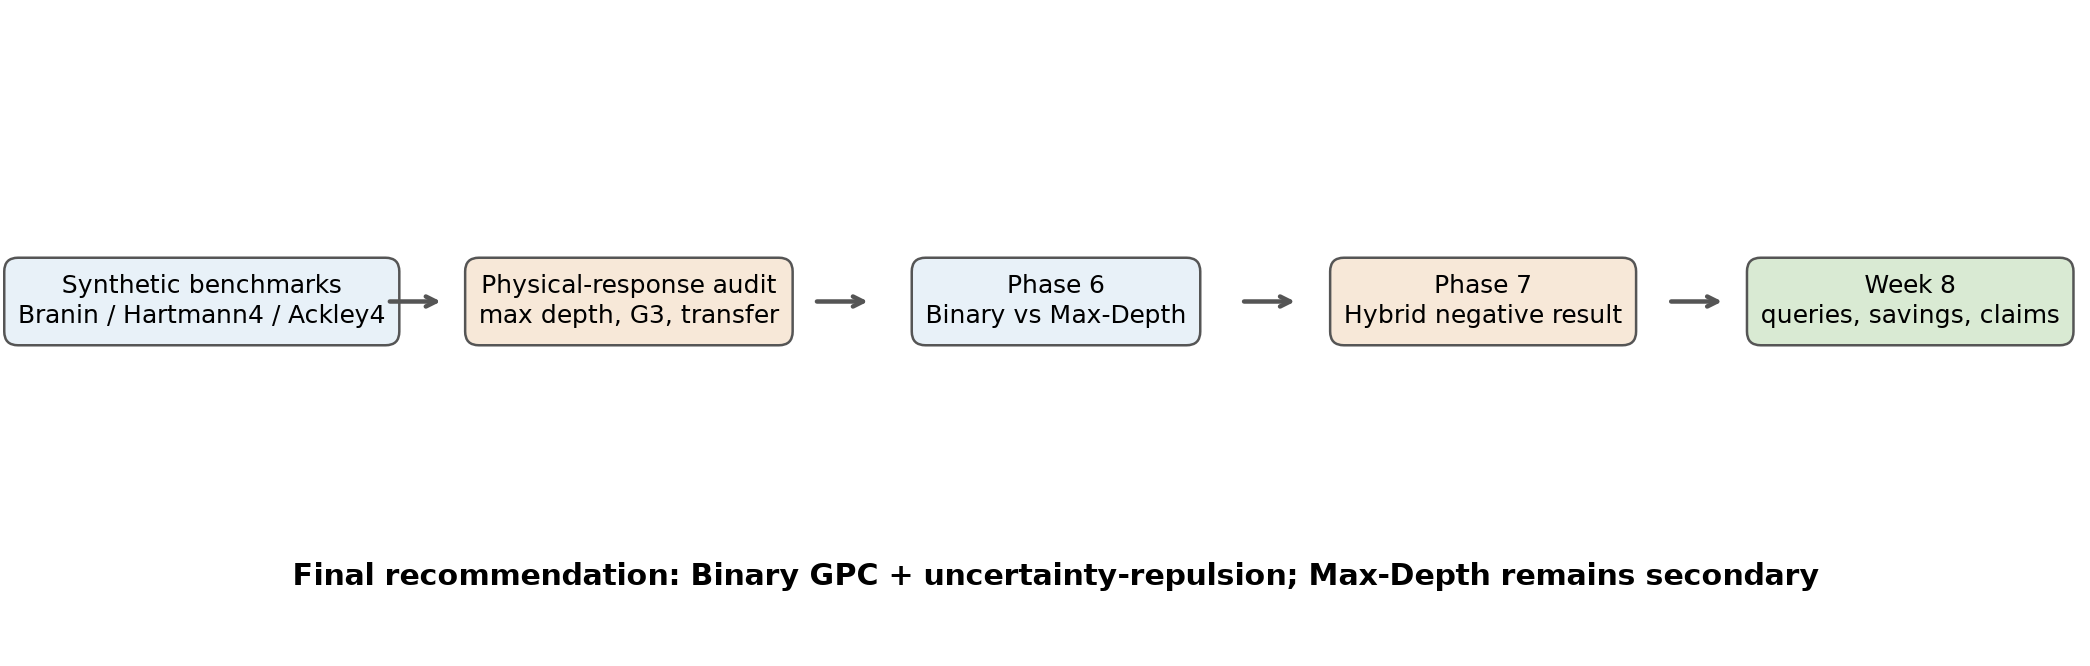

In [2]:
display(Image(filename=str(OUT2 / 'final_thesis_figures/01_full_thesis_evidence_chain.png')))

## 3. Synthetic benchmark summary

Branin, Hartmann4, and optional Ackley4 show that the best acquisition depends on geometry and metric.

**What does this mean in plain English?** Complex uncertainty reduction is not automatically better; boundary-specific evaluation can reorder global winners.

,benchmark,seed_count,best_q20_method,best_q20_error,best_sur_method,best_sur_q20_error,evidence_lesson
0,Branin,5,classifier_uncertainty_repulsion,0.256000,gpc_bernoulli_sur_refit_k15,0.265500,Simple uncertainty-repulsion wins q20; SUR com...
1,Hartmann4,5,gpc_bernoulli_sur_refit_k25,0.373000,gpc_bernoulli_sur_refit_k25,0.373000,SUR k25 wins q20 narrowly; method ranking depe...
2,"Ackley4 (optional, 3 seeds)",3,classifier_entropy,0.421167,gpc_bernoulli_sur_refit_k25,0.425667,Entropy/margin wins q20 while uncertainty-repu...


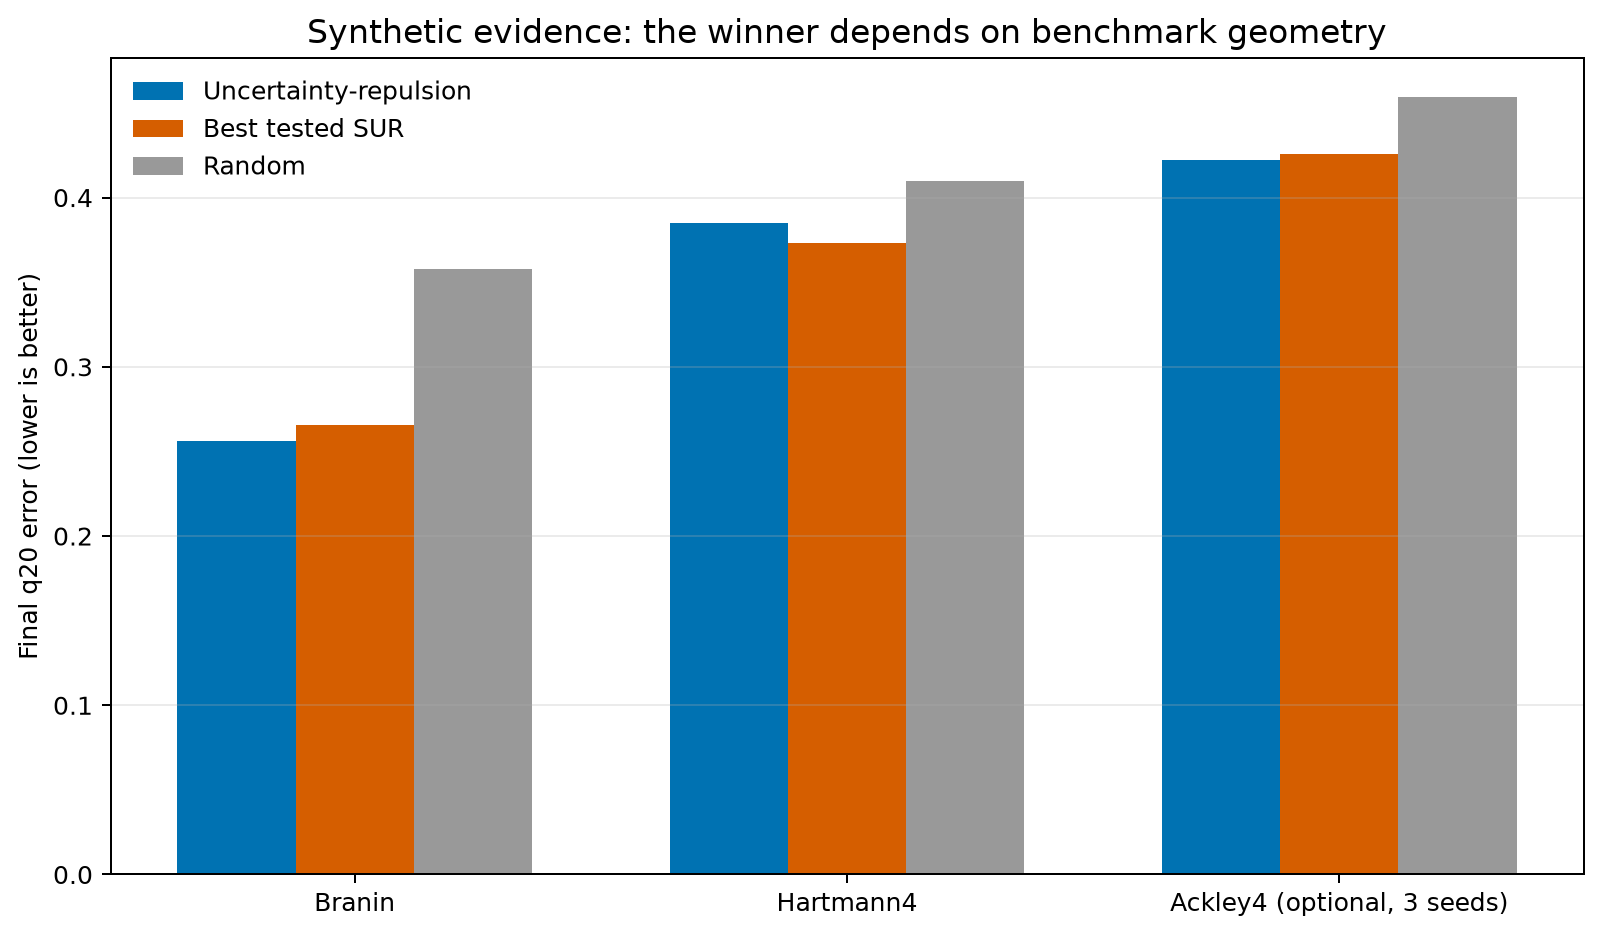

In [3]:
synthetic = pd.read_csv(OUT2 / "synthetic_to_real_summary.csv")
display(synthetic[["benchmark", "seed_count", "best_q20_method", "best_q20_error", "best_sur_method", "best_sur_q20_error", "evidence_lesson"]])
display(Image(filename=str(OUT2 / "final_thesis_figures/09_synthetic_to_real_summary.png")))

## 4. Week 7 real-data evidence chain

Manual has_keyhole stayed ground truth; maximum depth became the robust continuous comparator; Phase 6 exposed a boundary/global trade-off; Phase 7 rejected two fixed Hybrids.

**What does this mean in plain English?** Real data favored direct Binary boundary acquisition while preserving a meaningful Max-Depth secondary role.

In [4]:
phase6 = pd.read_csv(ROOT / "outputs/week7_06_real_data_boundary_active_level_set/phase6_formulation_scorecard.csv")
phase7 = pd.read_csv(ROOT / "outputs/week7_07_final_boundary_hybrid_benchmark/phase7_final_decision.csv")
display(phase6)
display(phase7)

,criterion,max_depth_value,binary_value,favours,status
0,primary_q20_aulc,0.205285,0.186236,binary,primary
1,primary_q30_aulc,0.150625,0.133203,binary,primary
2,balanced_accuracy_aulc,0.943215,0.917090,max_depth,primary_supporting
3,semantic_artifact_audit,0.000000,NaN,max_depth_defensible,supporting_not_relabelling
4,domain_transfer_floor,0.515873,0.745671,binary,secondary_robustness
5,online_threshold_stability_budget,20.500000,NaN,diagnostic,queried_set_stability_not_population_CI


,decision,reason,preregistered_rule_applied_mechanically,decision_rule_sha256,manual_has_keyhole_remains_ground_truth,maximum_depth_remains_physical_side_information,causal_claim,universal_physical_threshold_claim,hybrid_success_json
0,BINARY ACQUISITION PRIMARY,Neither Hybrid met the robust rule and Binary ...,True,a3581cb61c4b2f95aa71838fc9c199ca8f992fef7de671...,True,True,False,False,"{""hybrid_binary_gate20_max_depth_straddle"": fa..."


## 5. Final primary method

The frozen method maps P, VX, LS, and substrate temperature to P(Keyhole) and queries by uncertainty-repulsion.

**What does this mean in plain English?** B1/B2/B3 are downstream evaluation only; no hidden label or response enters acquisition.

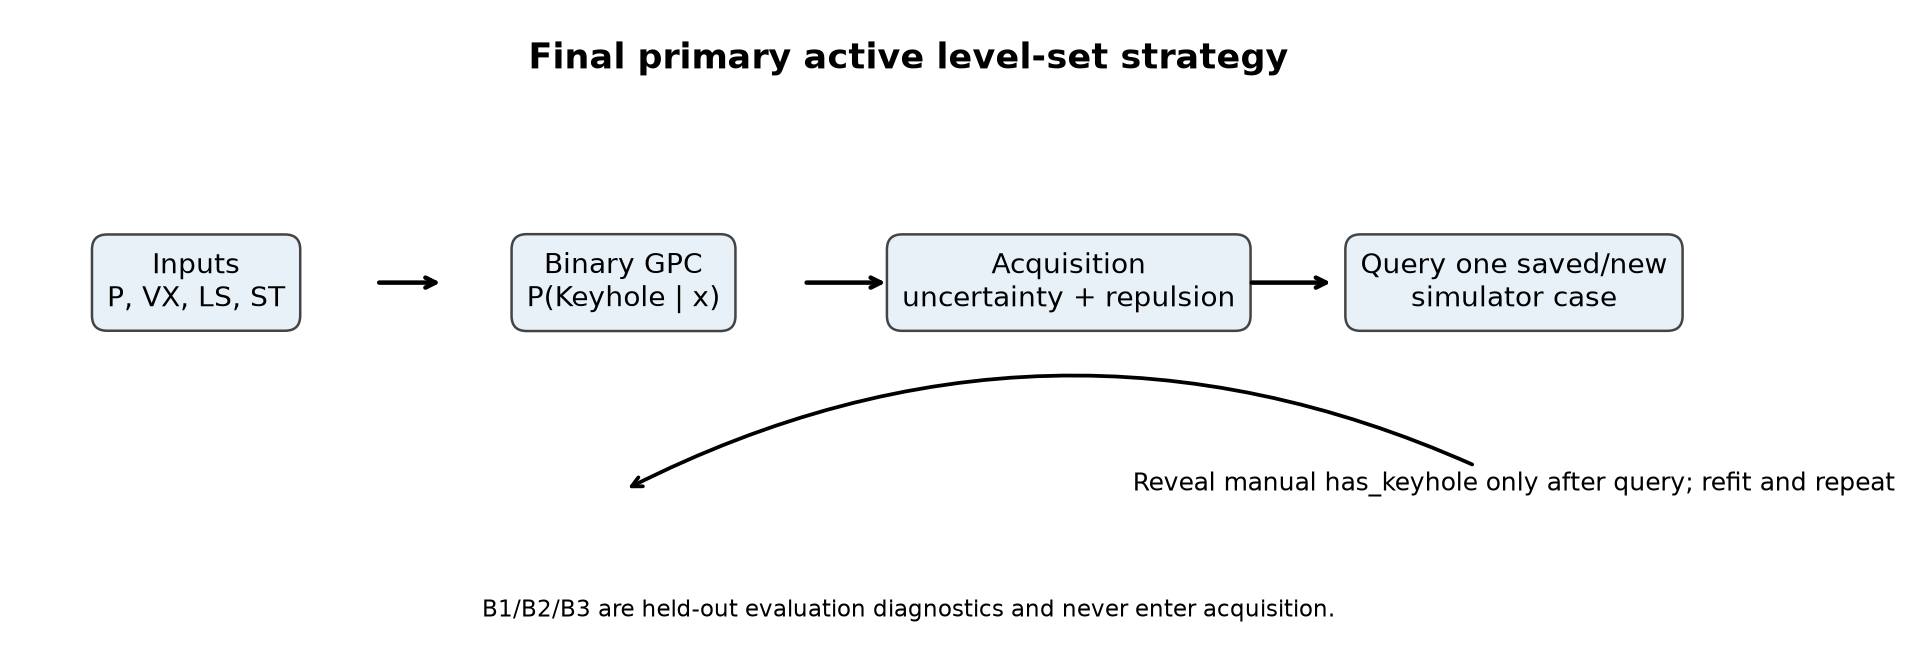

In [5]:
display(Image(filename=str(OUT2 / 'final_thesis_figures/10_final_method_schematic.png')))

## 6. Sample-efficiency headline table

The final snapshot table expresses q20/q30 accuracy at intuitive budgets.

**What does this mean in plain English?** Binary's boundary advantage and Max-Depth's global advantage are visible without combining them into an arbitrary weighted score.

In [6]:
snapshots = pd.read_csv(OUT1 / "budget_snapshot_b1.csv")
display(snapshots[snapshots["budget"].isin([20,30,40,50,60,70,80])][[
    "budget", "method_label", "mean_q20_accuracy", "mean_q30_accuracy", "mean_balanced_accuracy"
]].style.format({"mean_q20_accuracy":"{:.1%}","mean_q30_accuracy":"{:.1%}","mean_balanced_accuracy":"{:.1%}"}))

,budget,method_label,mean_q20_accuracy,mean_q30_accuracy,mean_balanced_accuracy
3,20,Binary,77.6%,83.2%,89.2%
4,20,Max-Depth,75.3%,80.8%,92.7%
5,20,Random,72.9%,79.4%,78.9%
6,30,Binary,79.7%,85.4%,91.0%
7,30,Max-Depth,79.1%,84.6%,94.3%
8,30,Random,77.4%,83.0%,86.4%
9,40,Binary,81.2%,86.2%,91.4%
10,40,Max-Depth,77.9%,84.0%,93.1%
11,40,Random,76.8%,83.2%,89.3%
12,50,Binary,82.9%,88.0%,92.4%


## 7. Queries and savings

Target crossings retain success counts; Random-equivalent savings do not extrapolate beyond 80.

**What does this mean in plain English?** The exact headline is 40 saved calls at Binary budget 30; budget-40 performance yields a strict >40 saving lower bound.

In [7]:
targets = pd.read_csv(OUT1 / "queries_to_accuracy_target.csv")
equivalent = pd.read_csv(OUT1 / "random_equivalent_budget.csv")
display(targets[(targets["boundary_definition"]=="B1") & (targets["target_accuracy_percent"].isin([80,85]))][[
    "quantile", "target_accuracy_percent", "method_label", "successful_runs", "median_queries_successful_runs", "not_reached_by_80"
]])
display(equivalent[["binary_budget", "binary_mean_accuracy", "random_equivalent_budget_display", "query_saving_display", "efficiency_multiplier_display"]])

,quantile,target_accuracy_percent,method_label,successful_runs,median_queries_successful_runs,not_reached_by_80
6,20,80,Binary,18,16.0,2
7,20,80,Max-Depth,15,15.0,5
8,20,80,Random,14,30.0,6
9,20,85,Binary,15,21.0,5
10,20,85,Max-Depth,12,18.5,8
11,20,85,Random,8,29.0,12
21,30,80,Binary,20,14.5,0
22,30,80,Max-Depth,20,14.5,0
23,30,80,Random,20,16.0,0
24,30,85,Binary,18,16.0,2


,binary_budget,binary_mean_accuracy,random_equivalent_budget_display,query_saving_display,efficiency_multiplier_display
0,20,0.776471,34.00,14.00,1.70x
1,30,0.797059,70.00,40.00,2.33x
2,40,0.811765,>80,>40,>2.00x
3,50,0.829412,>80,>30,>1.60x
4,60,0.835294,>80,>20,>1.33x


## 8. Boundary–global trade-off

B1-q20 accuracy AULC is plotted against balanced-accuracy AULC rather than collapsed into one post-hoc score.

**What does this mean in plain English?** Binary is preferred for the thesis boundary objective; Max-Depth is stronger for global classification.

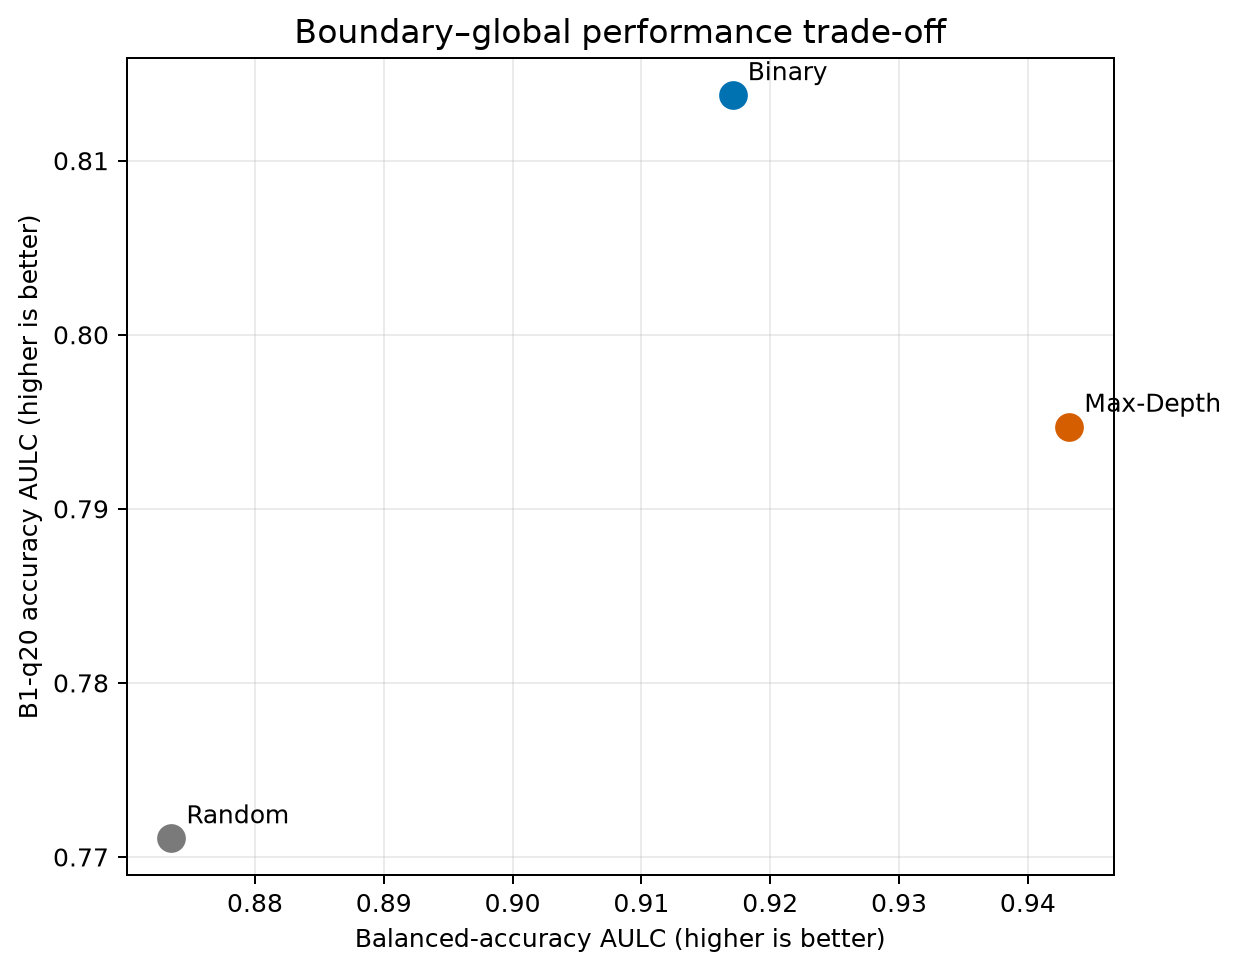

In [8]:
display(Image(filename=str(OUT2 / 'final_thesis_figures/07_boundary_global_tradeoff.png')))

## 9. Max-Depth secondary role

The final scorecard keeps its physical and predictive contribution explicit.

**What does this mean in plain English?** Max-Depth is not discarded; it simply does not replace the direct Binary boundary acquisition.

In [9]:
scorecard = pd.read_csv(OUT2 / "final_real_data_scorecard.csv")
display(scorecard[["method_label", "mean_B1_q20_accuracy_aulc", "mean_balanced_accuracy_aulc", "mean_sensitivity_aulc", "mean_keyhole_discovered_budget30", "primary_role"]])

,method_label,mean_B1_q20_accuracy_aulc,mean_balanced_accuracy_aulc,mean_sensitivity_aulc,mean_keyhole_discovered_budget30,primary_role
0,Binary,0.813764,0.917090,0.853160,12.20,final primary acquisition
1,Random,0.771071,0.873513,0.767325,5.45,authoritative random baseline
2,Max-Depth,0.794715,0.943215,0.937638,8.30,secondary continuous physical comparator


## 10. Negative Hybrid result

Gate20 and equal-rank fusion did not satisfy the preregistered robust rule and added local fitting overhead.

**What does this mean in plain English?** The defensible conclusion is narrow: the two tested Hybrids failed to improve the frozen Binary method.

In [10]:
outcome = pd.read_csv(ROOT / "outputs/week7_07_final_boundary_hybrid_benchmark/phase7_preregistered_rule_outcome.csv")
runtime = pd.read_csv(ROOT / "outputs/week7_07_final_boundary_hybrid_benchmark/phase7_runtime_comparison.csv")
display(outcome)
display(runtime[runtime["method"].str.contains("hybrid|binary_uncertainty")][["method", "mean_runtime_seconds", "relative_overhead_vs_binary_champion"]])

,method,condition_A_q20,q20_favourable_mean_definitions_json,q20_ci_below_zero_definitions_json,condition_B_q30,q30_favourable_mean_definitions_json,condition_C_no_material_BA_sacrifice,hybrid_BA_aulc,binary_BA_aulc,BA_difference_hybrid_minus_binary,condition_D_beats_shared_random,random_q20_favourable_mean_definitions_json,random_q20_ci_below_zero_definitions_json,all_preregistered_conditions_met,decision_rule_sha256
0,hybrid_binary_gate20_max_depth_straddle,False,[],[],False,[],False,0.898298,0.91709,-0.018792,True,"[""B1"", ""B2"", ""B3""]","[""B1"", ""B2"", ""B3""]",False,a3581cb61c4b2f95aa71838fc9c199ca8f992fef7de671...
1,hybrid_equal_rank_fusion,False,[],[],False,[],True,0.907595,0.91709,-0.009495,True,"[""B1"", ""B2"", ""B3""]","[""B1"", ""B2"", ""B3""]",False,a3581cb61c4b2f95aa71838fc9c199ca8f992fef7de671...


,method,mean_runtime_seconds,relative_overhead_vs_binary_champion
0,binary_uncertainty_repulsion,6.305875,1.000000
1,hybrid_binary_gate20_max_depth_straddle,9.060716,1.436869
2,hybrid_equal_rank_fusion,8.993251,1.426170


## 11. Final claim ledger

Supported claims, diagnostics, and prohibited overclaims are stored row by row with exact evidence paths.

**What does this mean in plain English?** The ledger prevents strong results from silently turning into universal, causal, or prospective claims.

In [11]:
ledger = pd.read_csv(OUT2 / "final_thesis_claim_ledger.csv")
display(ledger.groupby(["category", "status"]).size().rename("claim_count"))
display(ledger[["claim_id", "category", "claim", "status", "allowed_wording", "forbidden_overclaim"]])

category                                 status                           
CLAIMS WE MUST NOT MAKE                  NOT SUPPORTED / PROHIBITED           6
SUPPORTED PRIMARY CLAIMS                 SUPPORTED                            3
SUPPORTED SECONDARY / DIAGNOSTIC CLAIMS  SUPPORTED                            3
                                         SUPPORTED WITH CALIBRATION CAVEAT    1
Name: claim_count, dtype: int64

,claim_id,category,claim,status,allowed_wording,forbidden_overclaim
0,C01,SUPPORTED PRIMARY CLAIMS,Binary active learning is more sample-efficien...,SUPPORTED,Binary was more sample-efficient than Random f...,Binary is universally optimal or prospectively...
1,C02,SUPPORTED PRIMARY CLAIMS,Binary uncertainty-repulsion is the final prim...,SUPPORTED,The final recommended real-data strategy is Bi...,"The method dominates every target, metric, or ..."
2,C03,SUPPORTED SECONDARY / DIAGNOSTIC CLAIMS,Max-Depth has stronger global balanced-accurac...,SUPPORTED,Max-Depth is the stronger secondary global cla...,Max-Depth is therefore the best boundary-local...
3,C04,SUPPORTED PRIMARY CLAIMS,Max-Depth does not improve Binary boundary acq...,SUPPORTED,Neither of the two fixed Hybrids improved on B...,All possible hybrid uses of physical side info...
4,C05,SUPPORTED SECONDARY / DIAGNOSTIC CLAIMS,G3 perfectly separates new-data but has a part...,SUPPORTED,G3 is a strong scalar companion with partition...,G3 defines a universal morphology boundary.
5,C06,CLAIMS WE MUST NOT MAKE,A universal G3 threshold is supported.,NOT SUPPORTED / PROHIBITED,G3 thresholds transfer imperfectly and remain ...,One G3 cutoff universally separates Keyhole ph...
6,C07,CLAIMS WE MUST NOT MAKE,A universal Max-Depth threshold is supported.,NOT SUPPORTED / PROHIBITED,Max-Depth is a useful learned continuous compa...,The fitted depth threshold is a universal phys...
7,C08,CLAIMS WE MUST NOT MAKE,Input-response associations establish causal e...,NOT SUPPORTED / PROHIBITED,Inputs are associated with saved physical resp...,Changing an input causes the reported response...
8,C09,CLAIMS WE MUST NOT MAKE,B1/B2/B3 are the true continuous physical boun...,NOT SUPPORTED / PROHIBITED,B1/B2/B3 are empirical near-boundary diagnosti...,They locate the continuous physical transition...
9,C10,SUPPORTED SECONDARY / DIAGNOSTIC CLAIMS,No acquisition universally dominates every syn...,SUPPORTED,Method ranking depends on benchmark geometry a...,One acquisition is universally best.


## 12. Final thesis figures and tables

Only ten distinct final figures and six compact final tables are retained.

**What does this mean in plain English?** The final set is deliberately compact enough to map into Results and Discussion without a figure zoo.

In [12]:
figures = sorted((OUT2 / "final_thesis_figures").glob("*.png"))
tables = sorted((OUT2 / "final_thesis_tables").glob("*.csv"))
print("final figures:", len(figures))
print("final CSV tables:", len(tables))
display(pd.DataFrame({"figure": [path.name for path in figures]}))
display(pd.DataFrame({"table": [path.name for path in tables]}))

final figures: 10
final CSV tables: 6


,figure
0,01_full_thesis_evidence_chain.png
1,02_final_b1_q20_sample_efficiency.png
2,03_final_b1_q30_sample_efficiency.png
3,04_queries_to_target.png
4,05_random_equivalent_budget.png
5,06_keyhole_discovery.png
6,07_boundary_global_tradeoff.png
7,08_final_real_data_scorecard.png
8,09_synthetic_to_real_summary.png
9,10_final_method_schematic.png


,table
0,table1_final_dataset_population.csv
1,table2_final_sample_efficiency_budget_snapshot...
2,table3_queries_to_boundary_accuracy_targets.csv
3,table4_random_equivalent_simulator_savings.csv
4,table5_final_real_data_method_scorecard.csv
5,table6_supported_claim_ledger_summary.csv


## 13. Limitations

No genuinely new simulator evaluation was available. The 20 runs reuse 405 simulations in four repeated five-fold splits. Probability calibration is diagnostic.

**What does this mean in plain English?** The evidence supports retrospective sample efficiency, not live closed-loop deployment or certainty about a continuous physical surface.

In [13]:
limitations = ledger[ledger["category"] == "CLAIMS WE MUST NOT MAKE"][
    ["claim_id", "claim", "allowed_wording", "forbidden_overclaim", "caveat"]
]
display(limitations)

,claim_id,claim,allowed_wording,forbidden_overclaim,caveat
5,C06,A universal G3 threshold is supported.,G3 thresholds transfer imperfectly and remain ...,One G3 cutoff universally separates Keyhole ph...,Observed populations do not establish a physic...
6,C07,A universal Max-Depth threshold is supported.,Max-Depth is a useful learned continuous compa...,The fitted depth threshold is a universal phys...,Thresholds depend on sampled data and partition.
7,C08,Input-response associations establish causal e...,Inputs are associated with saved physical resp...,Changing an input causes the reported response...,No causal intervention design was analyzed.
8,C09,B1/B2/B3 are the true continuous physical boun...,B1/B2/B3 are empirical near-boundary diagnosti...,They locate the continuous physical transition...,Membership is sample-density and definition de...
10,C11,Repeated cross-validation is equivalent to ind...,The matched repeated-CV design quantifies retr...,Twenty independent simulator campaigns confirm...,Repeated folds are dependent through shared si...
11,C12,Prospective new-simulator validation was perfo...,Outputs were hidden until queried in an offlin...,The method was deployed in a live simulator loop.,Prospective confirmation remains future work.


## 14. Final conclusion

Week 8 closes the experimental program and hands a stable evidence chain to thesis writing.

**What does this mean in plain English?** The thesis can now make a concrete sample-efficiency claim while retaining honest limits on transfer, calibration, causality, and prospective validation.

In [14]:
print("FINAL PRIMARY: Binary GPC + binary_uncertainty_repulsion")
print("SECONDARY: Max-Depth straddle / physical comparator")
print("STRONGEST EXACT SAVING: 40 simulator calls for the 79.7% mean B1-q20 level")
print("BOUNDARY-40 LOWER BOUND: Random does not match Binary by 80 (>40 calls saved)")
print("EVIDENCE MODE: offline retrospective; no prospective simulator run")

FINAL PRIMARY: Binary GPC + binary_uncertainty_repulsion
SECONDARY: Max-Depth straddle / physical comparator
STRONGEST EXACT SAVING: 40 simulator calls for the 79.7% mean B1-q20 level
BOUNDARY-40 LOWER BOUND: Random does not match Binary by 80 (>40 calls saved)
EVIDENCE MODE: offline retrospective; no prospective simulator run
